## Cell 1 – יצירת ייצוג TF-IDF עבור הטקסטים

בשלב זה אנו טוענים את הדאטה המעובדת מתוך קובץ ה־CSV, וממירים את הטקסטים לייצוג מספרי באמצעות TF-IDF.  
שיטה זו מאפשרת למדוד את חשיבותה היחסית של כל מילה במסמך ביחס לכלל הקורפוס, ומהווה בסיס לשלבי ה־Clustering והמודלים הבאים.

**מה מתבצע בתא זה:**
- טעינת הדאטה לקובץ DataFrame.
- בניית וקטוריזר מסוג `TfidfVectorizer` עם עד 10,000 תכונות.
- המרת העמודה `text_full` למטריצת TF-IDF.
- הדפסת צורת (shape) המטריצה לצורך אימות.

מטריצת TF-IDF שתתקבל תשמש אותנו ליצירת האשכולות ולניתוח הסמנטי בהמשך התרגיל.


In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

file_path = "clean_data_set.csv"

df = pd.read_csv(file_path)


tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 1)
)

X_tfidf = tfidf_vectorizer.fit_transform(df['text_full'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (9999, 10000)


## Cell 2 – בחירת מספר האשכולות באמצעות Elbow Method ו־Silhouette Score

בשלב זה אנו מריצים את אלגוריתם **K-Means** עבור טווח ערכים של \( k = 2 \) עד \( k = 10 \), במטרה לזהות את מספר האשכולות האופטימלי.  
לשם כך נחשב שני מדדים מרכזיים:

###  1. **Inertia (Elbow Method)**  
מודד את סך המרחקים של הדגימות מהמרכז של האשכול אליו הן שייכות.  
ירידה חדה ולאחריה התיישרות (elbow) מצביעה על ערך \( k \) מתאים.

###  2. **Silhouette Score**  
מודד עד כמה הדגימות מופרדות היטב בין אשכולות שונים.  
ערך גבוה יותר מעיד על אשכולות מובחנים וברורים.

**בתא זה:**
- אנו מפעילים K-Means עבור כל ערך של \( k \).
- שומרים את ערכי ה־Inertia וה־Silhouette בכל איטרציה.
- מציגים את תוצאות המדדים לצורך בחירת \( k \) באופן מושכל.

השלב הזה מאפשר לקבוע את מספר האשכולות לפני הפעלת מודל הקלסטרינג הסופי.


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    print(f"Running KMeans for k={k} ...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_tfidf)

    inertia = kmeans.inertia_
    inertias.append(inertia)

    sil_score = silhouette_score(X_tfidf, kmeans.labels_)
    silhouettes.append(sil_score)

    print(f"k={k} -> inertia={inertia:.2f}, silhouette={sil_score:.4f}")


Running KMeans for k=2 ...
k=2 -> inertia=9640.97, silhouette=0.0052
Running KMeans for k=3 ...
k=3 -> inertia=9610.96, silhouette=0.0046
Running KMeans for k=4 ...
k=4 -> inertia=9547.24, silhouette=0.0061
Running KMeans for k=5 ...
k=5 -> inertia=9511.09, silhouette=0.0073
Running KMeans for k=6 ...
k=6 -> inertia=9495.12, silhouette=0.0071
Running KMeans for k=7 ...
k=7 -> inertia=9460.52, silhouette=0.0076
Running KMeans for k=8 ...
k=8 -> inertia=9446.02, silhouette=0.0080
Running KMeans for k=9 ...
k=9 -> inertia=9434.69, silhouette=0.0076
Running KMeans for k=10 ...
k=10 -> inertia=9412.58, silhouette=0.0081


## Cell 3 – ויזואליזציה לבחירת מספר האשכולות

לאחר חישוב מדדי ה־Inertia וה־Silhouette עבור טווח הערכים \( k = 2 \) עד \( k = 10 \),  
נבצע ויזואליזציה של שני הגרפים המרכזיים המסייעים בקביעת מספר האשכולות האופטימלי:

###  Elbow Method  
גרף המציג את ערכי ה־Inertia.  
חיפוש "נקודת הברך" מאפשר לזהות את הערך שבו הוספת אשכול נוסף כבר אינה משפרת משמעותית את איכות ההתאמה.

###  Silhouette Score  
גרף המציג את מידת ההפרדה בין האשכולות.  
ערכים גבוהים יותר מעידים על אשכולות מובחנים וברורים.

שני הגרפים יחד מאפשרים לבחור את ערך \( k \) המתאים ביותר להמשך הניתוח.


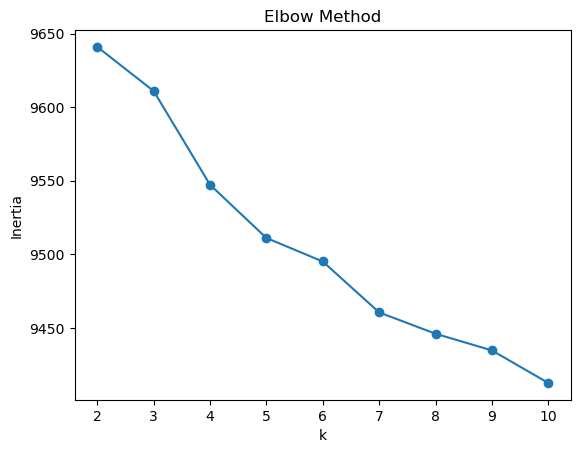

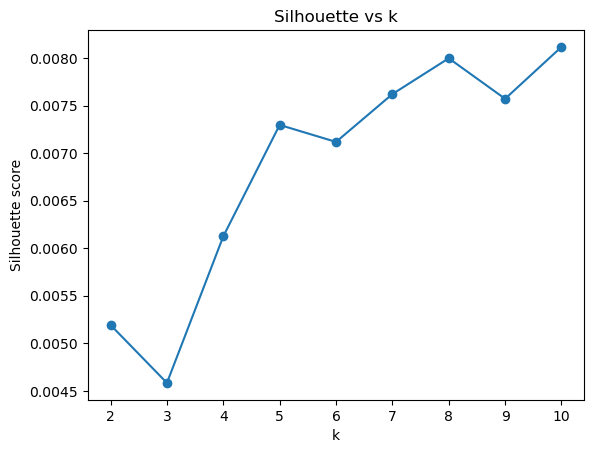

In [3]:
import matplotlib.pyplot as plt

plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.plot(list(k_values), silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k")
plt.show()

## Cell 4 – יצירת דנדרוגרמה עבור Hierarchical Clustering

בשלב זה אנו מבצעים ניתוח היררכי על תת־מדגם של 300 דגימות מתוך מטריצת ה־TF-IDF,  
וזאת משום שחישוב היררכי על כל הדאטה הוא יקר חישובית.

### מה נעשה בתא זה?

- בחירת 300 דוגמאות ראשונות לצורך דגימה.
- המרתן למערך צפוף (dense) מכיוון שהאלגוריתם `linkage` אינו תומך ב־sparse matrices.
- שימוש בשיטת Ward ליצירת מטריצת קישורים.
- הצגת **דנדרוגרמה** המציגה את מבנה האשכולות ההיררכי.

הדנדרוגרמה מאפשרת להבין את מבנה הדאטה ואת עומק הפיצול בין דגימות שונות,  
ומסייעת לקבל אינדיקציה ראשונית לגבי מספר אשכולות אפשרי בגישה היררכית.


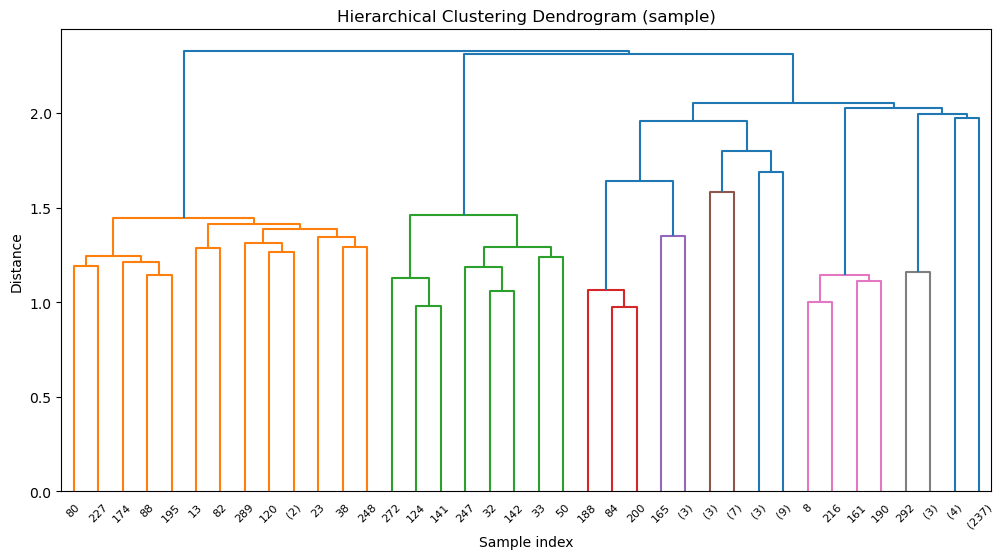

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample_size = 300
X_sample = X_tfidf[:sample_size]

X_sample_dense = X_sample.toarray()

Z = linkage(X_sample_dense, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram (sample)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()


## Cell 5 – הפחתת ממדים באמצעות TruncatedSVD

מאחר שמטריצת ה־TF-IDF בעלת מספר תכונות גבוה מאוד,  
נשתמש ב־**TruncatedSVD** כדי להקטין את הממדיות ולהקל על אלגוריתמי clustering מסוימים — בפרט Hierarchical Clustering,  
שאינו מתמודד היטב עם מרחבים בעלי מאות אלפי ממדים.

### מה מתבצע בתא זה?

- הפעלת `TruncatedSVD` עם 100 רכיבים בלבד.
- התאמת המודל על מטריצת ה־TF-IDF.
- הפחתת הממדיות ויצירת מטריצה חדשה `X_reduced`.
- הדפסת צורת המטריצה המוקטנת.

הפחתת ממדים זו שומרת על רוב המידע הסמנטי,  
ומאפשרת חישוב יעיל ומהיר יותר בשלבים הבאים.


In [5]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

print(X_reduced.shape)

(9999, 100)


## Cell 6 – הפעלת Hierarchical Clustering על הדאטה המוקטנת

לאחר הפחתת הממדיות באמצעות TruncatedSVD,  
נבצע clustering היררכי מסוג **Agglomerative Clustering** במטרה להשוות את התוצאות לשיטת K-Means.

### פרטי האלגוריתם:
- מספר האשכולות מוגדר ל־4 (בהתאם למספר שנבחר בשלב ה־K-Means).
- משתמשים במרחק **cosine**, המתאים במיוחד לנתוני טקסט ו־TF-IDF.
- שיטת הקישור היא **average**, אשר טובה למבנים סמנטיים מפוזרים.

### מה מתבצע בתא זה?
- התאמת המודל על המטריצה המוקטנת `X_reduced`.
- קבלת תוויות אשכול (`hc_labels`) לכל דגימה.
- הוספת התוויות לדאטה במסגרת העמודה `hc_cluster`.
- הצגת התפלגות הדגימות בין האשכולות.

שלב זה מאפשר להשוות בין התנהגות clustering היררכי לבין תוצאות K-Means,
ולבחון האם שתי השיטות מזהות מבנים דומים בדאטה.


In [6]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    metric="cosine",
    linkage="average"
)

hc_labels = hc.fit_predict(X_reduced)

df["hc_cluster"] = hc_labels
print(df["hc_cluster"].value_counts())

hc_cluster
0    9749
2     182
3      39
1      29
Name: count, dtype: int64


## Cell 7 – הפעלת מודל K-Means הסופי עם מספר האשכולות שנבחר

לאחר ניתוח מדדי ה־Elbow וה־Silhouette, נבחר הערך **k = 4** כמספר האשכולות האופטימלי.  
בשלב זה אנו מפעילים את מודל ה־K-Means הסופי על כל הדאטה.

### מה מתבצע בתא זה?

- יצירת מודל `KMeans` עם 4 אשכולות.
- התאמתו על מטריצת ה־TF-IDF המלאה.
- קבלת תוויות אשכול (`kmeans_labels`) לכל דגימה.
- הוספת התוויות לעמודת `kmeans_cluster` במסגרת ה־DataFrame.
- הצגת התפלגות הדגימות בין האשכולות.

מודל זה ישמש אותנו בהמשך לניתוח מילות מפתח בכל אשכול ולבניית מודל זיהוי נושאים (Topic Modeling).


In [7]:
from sklearn.cluster import KMeans

k_optimal = 4

final_kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

final_kmeans.fit(X_tfidf)

kmeans_labels = final_kmeans.labels_

df["kmeans_cluster"] = kmeans_labels

print(df["kmeans_cluster"].value_counts())

kmeans_cluster
0    3741
1    3735
2    1996
3     527
Name: count, dtype: int64


## Cell 8 – זיהוי המילים המשמעותיות ביותר בכל אשכול

בשלב זה אנו מנתחים את מרכזי האשכולות (Cluster Centroids) של מודל ה־K-Means  
כדי לזהות את **15 המילים הבולטות** שמאפיינות כל אשכול.

### מה מתבצע בתא?

- שליפת רשימת המאפיינים (`feature_names`) מתוך וקטור ה־TF-IDF.
- עבור כל אשכול:
  - שליפת וקטור המרכז (Centroid).
  - מיון הערכים לפי משקל TF-IDF הגבוה ביותר.
  - הצגת 15 המילים המובילות שמופיעות בתדירות משמעותית באשכול.

### מטרת הניתוח
מילים אלו מסייעות להבין את הנושא המרכזי של כל אשכול  
ומשמשות בסיס בשלב הבא להגדרת כותרות (Topics) עבור האשכולות במסגרת שלב ה־Topic Modeling.


In [8]:
feature_names = tfidf_vectorizer.get_feature_names_out()

for cluster_id in range(4):
    print(f"\nCluster {cluster_id}")

    center = final_kmeans.cluster_centers_[cluster_id]

    top_idx = center.argsort()[-15:][::-1]
    top_words = [feature_names[i] for i in top_idx]

    print("Top words:", top_words)


Cluster 0
Top words: ['product', 'experience', 'make', 'bad', 'quality', 'try', 'like', 'hate', 'use', 'frustrate', 'left', 'do', 'feature', 'recommend', 'moment']

Cluster 1
Top words: ['highly', 'use', 'joy', 'love', 'minor', 'look', 'amaze', 'recommend', 'absolutely', 'truly', 'set', 'impressed', 'product', 'new', 'recently']

Cluster 2
Top words: ['do', 'bit', 'overall', 'particularly', 'experience', 'job', 'use', 'appreciate', 'look', 'okay', 'just', 'product', 'try', 'hand', 'like']

Cluster 3
Top words: ['game', 'play', 'graphic', 'experience', 'gameplay', 'quest', 'storyline', 'character', 'control', 'level', 'engage', 'challenge', 'world', 'console', 'controller']


## Cell 9 – ויזואליזציה דו־ממדית של האשכולות באמצעות PCA

בשלב זה אנו מצמצמים את מטריצת ה־TF-IDF למרחב דו־ממדי באמצעות אלגוריתם **PCA**,  
ומציגים את פיזור הדגימות בהתאם לתוויות האשכולות של K-Means.

### מה מתבצע בתא?

- המרת מטריצת ה־TF-IDF לפורמט צפוף (`toarray()`), הנדרש עבור PCA.
- הפעלת PCA עם שני רכיבים בלבד (2D).
- הקרנת כל הדגימות למרחב דו־ממדי.
- שרטוט פיזור הנקודות, כאשר כל נקודה צבועה בהתאם לאשכול אליו היא שייכת.

### מטרת הוויזואליזציה
הגרף מאפשר להבין האם קיימת **הפרדה חזותית** בין האשכולות  
וכיצד הדאטה מתפזרת ביחס לרכיבים העיקריים.  
למרות הדחיסה המשמעותית של המידע, ניתן לקבל אינדיקציה על איכות ה־clustering  
ועל המבנה הסמנטי של הדאטה.


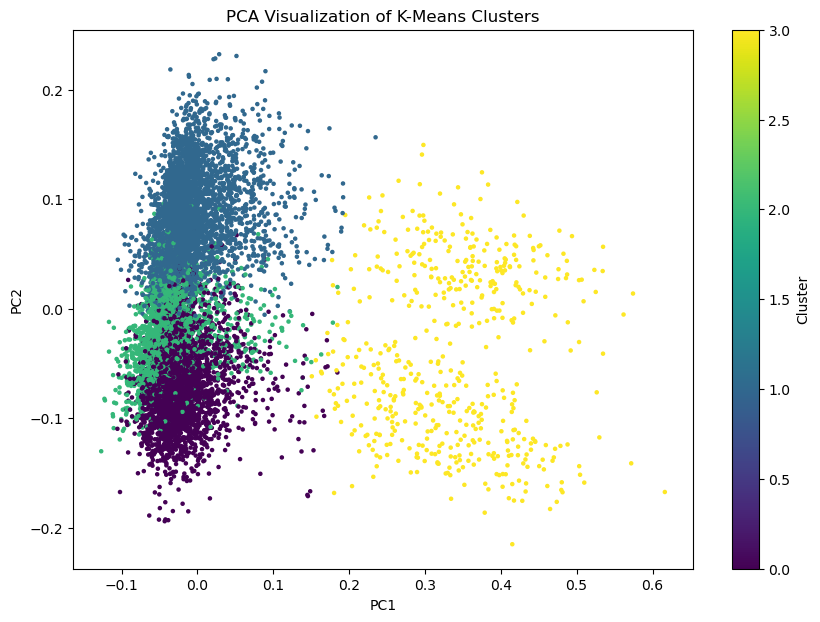

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10,7))
plt.scatter(X_pca[:,0], X_pca[:,1], c=final_kmeans.labels_, cmap='viridis', s=5)
plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()


## Cell 10 – חישוב מדד ARI לצורך הערכת איכות ה־Clustering

בשלב זה אנו מחשבים את **Adjusted Rand Index (ARI)** כדי לבדוק עד כמה תוצאות ה־K-Means  
מתואמות עם התוויות המקוריות של הדאטה — במקרה זה, דירוגי הכוכבים (`rating`).

###  מהו ARI?
מדד ARI מודד דמיון בין שיוך אשכולות לבין תוויות אמת:  
- ערך **1** → התאמה מושלמת  
- ערך **0** → ביצוע אקראי לחלוטין  
- ערך **שלילי** → גרוע מאקראי

###  מה נעשה בתא?
- השוואת תוויות האשכולות (`final_kmeans.labels_`) לדירוגי הכוכבים המקוריים.
- הדפסת ערך ה־ARI.

מדד זה מספק נקודת מבט נוספת על איכות האשכולות,  
אך חשוב לזכור ש־K-Means אינו מיועד לשחזר דירוגים —  
ולכן ההתאמה אינה חייבת להיות גבוהה כדי שהאשכולות יהיו משמעותיים סמנטית.


In [10]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df["rating"], final_kmeans.labels_)
print("ARI:", ari)

ARI: 0.5623248465797355


## Cell 11 – חישוב מדד Purity להערכת איכות האשכולות

בשלב זה אנו מחשבים את מדד **Purity**, המשמש להערכת עד כמה כל אשכול "נקי"  
ומכיל דגימות השייכות לקטגוריה הדומיננטית בתוויות האמת.

###  איך מחושב Purity?
לכל אשכול:
1. מאתרים את כל הדגימות השייכות אליו.  
2. מוצאים את התווית הנפוצה ביותר (Mode) באותו אשכול.  
3. סוכמים את כמות הדגימות שנשאו את התווית הדומיננטית.  

Purity = (מספר הדגימות שתוייגו נכון) / (סך כל הדגימות)

###  מה חשוב לדעת?
מדד Purity רגיש מאוד לחלוקה טבעית של הדאטה.  
בדאטה הנוכחית, דירוגי הכוכבים אינם מבטאים נושא (topic) אלא רמת שביעות רצון,  
בעוד שה־clustering מבוסס TF-IDF מזהה **נושאים ומבנים סמנטיים** — ולכן ציפייה לערך Purity גבוה אינה מתאימה למקרה זה.

###  בתא זה:
- מחשבים את Purity בין תוויות האמת (`rating`) לבין תוויות ה־K-Means.  
- מדפיסים את ערך הניקיון הכולל.

תוצאה נמוכה אינה מעידה על כשל, אלא על כך שהאשכולות משקפים **נושאים שונים** ולא את דירוגי הכוכבים המקוריים.


In [11]:
import numpy as np
from scipy.stats import mode

def purity_score(labels_true, labels_pred):
    clusters = np.unique(labels_pred)
    total = len(labels_pred)
    correct = 0

    for cluster in clusters:
        idx = np.where(labels_pred == cluster)[0]
        true_labels = labels_true[idx]
        correct += mode(true_labels, keepdims=True)[0][0].size

    return correct / total

purity = purity_score(df["rating"].values, final_kmeans.labels_)
print("Purity:", purity)

Purity: 0.00040004000400040005


## Cell 12 – הרצת LDA בתוך כל אשכול לצורך זיהוי נושאים מרכזיים

בשלב זה אנו מפעילים מודל **LDA – Latent Dirichlet Allocation** באופן נפרד על כל אשכול,  
במטרה לזהות את המילים הדומיננטיות (Topics) שמאפיינות את הטקסטים באותו אשכול.

###  מה מתבצע בתא?

1. **שליפת הטקסטים של האשכול** מתוך העמודה `tokens_full`.
2. **ניקוי והמרת הטוקנים**:  
   הדאטה עשויה להכיל רשימות אמיתיות או מחרוזות, ולכן אנו מבטיחים שכל מסמך יומר לרשימת מילים תקינה.
3. **בניית מילון (Dictionary)** המתאר את כל המילים באשכול.
4. **סינון מילים נדירות או נפוצות מדי** (`filter_extremes`).
5. **המרת כל מסמך ל־Bag-of-Words** לצורך יצירת Corpus מאוזן.
6. **הרצת מודל LDA** עם מספר נושאים מוגדר מראש (ברירת מחדל: 2).
7. **הדפסת הנושאים שנוצרו**, כולל 10 המילים המובילות בכל Topic.

###  מטרת השלב
מודל LDA מאפשר לנו להבין את הסמנטיקה של כל אשכול,  
ולהגדיר לו כותרת המתארת את הנושא המשותף לטקסטים שבו.  
זיהוי הנושאים יסייע בשלב הבא למידול טופיק מדויק ובהסקת כותרות לכל אשכול.



In [12]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import ast

def run_lda_for_cluster(cluster_id, num_topics=2, passes=10):
    cluster_df = df[df["kmeans_cluster"] == cluster_id]
    raw_docs = cluster_df["tokens_full"].tolist()

    print(f"Cluster {cluster_id} - number of docs:", len(raw_docs))

    if len(raw_docs) < 10:
        print("its too small")
        return None, None, None

    cluster_tokens = []
    for doc in raw_docs:
        if isinstance(doc, list):
            cluster_tokens.append(doc)
        elif isinstance(doc, str):
            if doc.startswith("[") and doc.endswith("]"):
                try:
                    parsed = ast.literal_eval(doc)
                    cluster_tokens.append(parsed)
                except Exception:
                    cluster_tokens.append(doc.split())
            else:
                cluster_tokens.append(doc.split())
        else:
            cluster_tokens.append(str(doc).split())

    dictionary = Dictionary(cluster_tokens)
    dictionary.filter_extremes(no_below=5, no_above=0.5)

    corpus = [dictionary.doc2bow(tokens) for tokens in cluster_tokens]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        random_state=42
    )

    print(f"\n=== Topics for cluster {cluster_id} ===")
    for topic_id in range(num_topics):
        print(f"\nTopic {topic_id}:")
        print(lda_model.print_topic(topic_id, topn=10))

    return lda_model, dictionary, corpus

## Cell 13 – הרצת LDA עבור כל אשכול בנפרד

בשלב זה אנו מפעילים את פונקציית `run_lda_for_cluster` על ארבעת האשכולות שלמודל K-Means יצר.  
המטרה היא לזהות את הנושאים (Topics) המאפיינים כל אשכול, ולהבין מהו הרעיון המרכזי שמקבץ את המסמכים יחד.

###  מה מתבצע בתא?

- מעבר על כל אשכול (`cluster_id` בין 0 ל־3).
- הרצת מודל LDA עם:
  - `num_topics=2` – שני נושאים לכל אשכול.
  - `passes=10` – להרצת אימון מעמיקה יותר.
- הדפסת הנושאים והמילים הדומיננטיות בכל אשכול.
- שמירת תוצאות ה־LDA במבנה `lda_results` לצורך שימוש עתידי.

###  מטרת השלב

בעזרת LDA אנו יכולים:
- לזהות את המילים החוזרות בכל אשכול.
- להבין טוב יותר את האופי הסמנטי של כל Cluster.
- לבסס בחירת כותרת (Topic Label) מתאימה עבור האשכול בשלב הדו״ח.



In [13]:
lda_results = {}

for cid in range(4):
    print("\n" + "="*60 + f"\nRunning LDA for cluster {cid}\n" + "="*60)
    lda_model, dictionary, corpus = run_lda_for_cluster(
        cluster_id=cid,
        num_topics=2,
        passes=10
    )
    lda_results[cid] = (lda_model, dictionary, corpus)


Running LDA for cluster 0
Cluster 0 - number of docs: 3741

=== Topics for cluster 0 ===

Topic 0:
0.009*"feature" + 0.008*"quality" + 0.008*"overall" + 0.008*"do" + 0.008*"try" + 0.007*"time" + 0.007*"use" + 0.007*"frustrate" + 0.007*"design" + 0.007*"like"

Topic 1:
0.011*"like" + 0.010*"use" + 0.009*"look" + 0.009*"do" + 0.009*"try" + 0.008*"overall" + 0.008*"bad" + 0.007*"feel" + 0.007*"left" + 0.007*"quality"

Running LDA for cluster 1
Cluster 1 - number of docs: 3735

=== Topics for cluster 1 ===

Topic 0:
0.008*"design" + 0.007*"minor" + 0.007*"absolutely" + 0.007*"make" + 0.007*"recently" + 0.006*"joy" + 0.006*"love" + 0.006*"set" + 0.006*"_date_" + 0.006*"product"

Topic 1:
0.011*"product" + 0.008*"absolutely" + 0.008*"feel" + 0.007*"like" + 0.007*"love" + 0.007*"make" + 0.006*"truly" + 0.006*"new" + 0.006*"just" + 0.006*"skin"

Running LDA for cluster 2
Cluster 2 - number of docs: 1996

=== Topics for cluster 2 ===

Topic 0:
0.014*"product" + 0.011*"try" + 0.010*"like" + 0.0

## Cell 14 – הרצת LDA על כל הקורפוס לקבלת נושאים גלובליים

בנוסף ל־LDA לכל אשכול בנפרד, אנו מריצים מודל LDA על **כל הקורפוס כולו**.  
מטרת שלב זה היא לזהות את הנושאים המרכזיים המופיעים בכלל הדאטה, ולהבין את מבנה הטקסטים ברמת המאקרו.

###  מה מתבצע בתא?

1. **עיבוד הטוקנים** עבור כלל המסמכים, תוך התאמה למקרים בהם הנתונים הם:
   - רשימות מילים (`list`)
   - מחרוזות המייצגות רשימות (`"[...]"`)
   - טקסט חופשי הדורש `split()`

2. **בניית מילון גלובלי (Dictionary)** המתאר את כל מילות הקורפוס.

3. **סינון מילים נדירות או נפוצות מדי** באמצעות:
   ```python
   filter_extremes(no_below=10, no_above=0.5)


In [14]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel

all_docs = df["tokens_full"].tolist()

from ast import literal_eval

processed_docs = []
for doc in all_docs:
    if isinstance(doc, list):
        processed_docs.append(doc)
    elif isinstance(doc, str):
        try:
            processed_docs.append(literal_eval(doc))
        except Exception:
            processed_docs.append(doc.split())
    else:
        processed_docs.append(str(doc).split())

all_dictionary = Dictionary(processed_docs)
all_dictionary.filter_extremes(no_below=10, no_above=0.5)

all_corpus = [all_dictionary.doc2bow(tokens) for tokens in processed_docs]

all_lda = LdaModel(
    corpus=all_corpus,
    id2word=all_dictionary,
    num_topics=6,
    passes=10,
    random_state=42
)

for topic_id in range(6):
    print(f"\nGlobal Topic {topic_id}:")
    print(all_lda.print_topic(topic_id, topn=10))



Global Topic 0:
0.016*"highly" + 0.013*"minor" + 0.012*"love" + 0.012*"joy" + 0.011*"absolutely" + 0.011*"use" + 0.010*"amaze" + 0.010*"truly" + 0.010*"recently" + 0.009*"impressed"

Global Topic 1:
0.034*"do" + 0.016*"bit" + 0.011*"particularly" + 0.011*"use" + 0.010*"appreciate" + 0.010*"recently" + 0.009*"product" + 0.009*"just" + 0.008*"easy" + 0.008*"option"

Global Topic 2:
0.013*"feature" + 0.012*"product" + 0.011*"_date_" + 0.011*"use" + 0.009*"make" + 0.009*"time" + 0.008*"do" + 0.008*"issue" + 0.007*"frustrate" + 0.007*"design"

Global Topic 3:
0.012*"make" + 0.012*"like" + 0.011*"product" + 0.011*"design" + 0.010*"quality" + 0.009*"bad" + 0.009*"moment" + 0.009*"try" + 0.008*"material" + 0.008*"absolutely"

Global Topic 4:
0.035*"game" + 0.017*"play" + 0.012*"toy" + 0.009*"engage" + 0.008*"feel" + 0.008*"like" + 0.008*"movie" + 0.007*"sound" + 0.007*"do" + 0.007*"unique"

Global Topic 5:
0.025*"product" + 0.016*"use" + 0.012*"do" + 0.012*"try" + 0.011*"skin" + 0.010*"like" 

## Cell 15 – שליפת משפטים מייצגים מתוך כל אשכול

כדי לבצע ניתוח קשרים (Relation Extraction) בשלב הבא,  
נדרשת גישה למספר משפטים אמיתיים מתוך כל אשכול.

הפונקציה `get_sentences_from_cluster` מבצעת:

###  מה הפונקציה עושה?
- מסננת את הדאטה לפי מספר האשכול (`kmeans_cluster`).
- שולפת את הטקסטים המלאים מתוך העמודה `text_full`.
- מחזירה **עד 30 משפטים** ראשונים מהאשכול (או כל מספר שנבחר).

###  מטרת השלב
יצירת תת־דגימה מייצגת מכל Cluster לצורך:
- חילוץ קשרים תחביריים  
- ניתוח לשוני  
- השוואה בין האשכולות

שלב זה חיוני להתחלת פרק Relation Extraction.


In [15]:
def get_sentences_from_cluster(cluster_id, n=30):
    cluster_texts = df[df["kmeans_cluster"] == cluster_id]["text_full"].tolist()
    selected = cluster_texts[:n]
    return selected

## Cell 16 – טעינת מודל SpaCy לצורך ניתוח לשוני מתקדם

בשלב זה אנו טוענים את מודל **SpaCy Transformer (en_core_web_trf)**,  
אחד המודלים המתקדמים ביותר לניתוח שפה טבעית באנגלית.

###  מה המודל מאפשר לנו?

- חלוקת משפטים (Sentence Segmentation)
- זיהוי חלקי דיבר (POS Tagging)
- ניתוח תחבירי (Dependency Parsing)
- זיהוי ישויות בשם (NER)
- חילוץ קשרים תחביריים (SVO)

###  למה להשתמש במודל זה?

המודל מבוסס Transformer (בדומה ל־BERT),  
ומספק דיוק גבוה במיוחד — תכונה חשובה לשלב **Relation Extraction**,  
בו אנו זקוקים להבנה תחבירית מדויקת של המשפטים.

בהמשך נשתמש במודל זה כדי לחלץ קשרים סמנטיים מתוך משפטים בכל אשכול.


In [16]:
import spacy
import textacy

nlp = spacy.load("en_core_web_trf")  

## Cell 17 – המרת משפטים לאובייקטי SpaCy Doc

כדי לבצע ניתוח תחבירי וחילוץ קשרים מכל משפט,  
נדרשת המרה של כל משפט לאובייקט `Doc` של SpaCy.

###  מה הפונקציה עושה?

- מקבלת רשימת משפטים (`sent_list`).
- מפעילה על כל משפט את המודל `nlp` של SpaCy.
- מחזירה רשימה של אובייקטים מסוג `Doc`.

###  למה זה חשוב?

אובייקט `Doc` מאפשר גישה לכלי העיבוד של SpaCy:
- זיהוי מבנה תחבירי  
- זיהוי ישויות  
- חילוץ קשרי SVO  
- ניתוח טוקנים וקשרים ביניהם

זהו שלב הכנה חיוני לפני שלב Relation Extraction.


In [17]:
def spacy_docs_from_sentences(sent_list):
    docs = [nlp(sent) for sent in sent_list]
    return docs

## Cell 18 – חילוץ קשרי SVO (Subject–Verb–Object)

קשרים מסוג **SVO** הם אחד המבנים התחביריים המרכזיים באנגלית,  
ומאפשרים לזהות מי מבצע פעולה ומהו האובייקט המושפע ממנה.  
מבנים אלה נפוצים מאוד בביקורות משתמשים ולכן הם בסיס חיוני ל־Relation Extraction.

###  מה הפונקציה עושה?

- מקבלת אובייקט SpaCy `Doc`.
- משתמשת ב־Textacy כדי לחלץ את כל קשרי **Subject–Verb–Object** מהמשפט.
- ממירה את הישויות המוחזרות לטקסט מלא (ולא לטוקנים בודדים).
- מחזירה רשימת טריפלטים במבנה:
###  למה זה חשוב?
קשרים מסוג SVO מאפשרים לזהות:
- תיאורי פעולה ("user *loves* product")
- בעיות ("device *fails* connection")
- חוויות שימוש ("game *offers* challenge")
וזהו סוג הקשר המרכזי שיופיע בדאטה של ביקורות מוצרים.

In [18]:
def extract_SVO(doc):
    triples = []
    for subj, verb, obj in textacy.extract.subject_verb_object_triples(doc):
        subj_text = " ".join(tok.text for tok in subj)
        verb_text = " ".join(tok.text for tok in verb)
        obj_text = " ".join(tok.text for tok in obj)
        triples.append((subj_text, verb_text, obj_text))
    return triples


## Cell 19 – חילוץ קשרי Entity–Location

פונקציה זו מיועדת לזהות קשרים תחביריים המתארים פעולה הקשורה למיקום,  
למשל:  
- *“device is installed **in** house”*  
- *“user lives **at** home”*  

מבנים כאלה נדירים יחסית בביקורות מוצרים, אך הם חלק ממערך בדיקות היחסים.

###  מה הפונקציה עושה?

- סורקת כל משפט (`doc.sents`).
- מאתרת פעלים (VERB).
- מזהה נושא הקשור לפועל (nsubj).
- מחפשת מילות יחס רלוונטיות למיקום: **in**, **at**, **from**.
- מאתרת את שם העצם המשויך למילת היחס (pobj).
- מחזירה קשר במבנה:


In [19]:
def extract_entity_location(doc):
    relations = []
    for sent in doc.sents:
        for verb in sent:
            if verb.pos_ == "VERB":
                subj = next((child for child in verb.children if child.dep_ == "nsubj"), None)
                if not subj:
                    continue

                for prep in verb.children:
                    if prep.dep_ == "prep" and prep.text.lower() in {"in", "at", "from"}:
                        pobj = next((child2 for child2 in prep.children if child2.dep_ == "pobj"), None)
                        if pobj:
                            relations.append((subj.text, f"{verb.text} {prep.text}", pobj.text))
    return relations

## Cell 20 – חילוץ קשרי Entity–Attribute

פונקציה זו מזהה מבנים תחביריים שבהם ליישות כלשהי מיוחסת תכונה (Attribute),  
לרוב באמצעות פועל מקשר כמו *is*, *feels*, *seems* ועוד.

מבנים אפשריים:
- *“product **is** amazing”*  
- *“gameplay **feels** smooth”*

###  מה הפונקציה עושה?

- סורקת את כל הטוקנים במשפט.
- מאתרת טוקנים שתפקידם התחבירי הוא **acomp**  
  (תואר המהווה חלק ממשפט ייחוס – adjectival complement).
- מאתרת את הפועל המשויך לתואר (`token.head`).
- מחפשת את הנושא של הפועל (nsubj).
- מחזירה קשר במבנה:


In [20]:
def extract_entity_attribute(doc):
    relations = []
    for token in doc:
        if token.dep_ == "acomp":
            verb = token.head
            subj = next((child for child in verb.children if child.dep_ == "nsubj"), None)
            if subj:
                relations.append((subj.text, verb.lemma_, token.text))
    return relations

## Cell 21 – חילוץ קשרי Product–is–Adjective (יחסי ייחוס רגשיים)

בשלב זה אנו מגדירים פונקציה ייעודית לזיהוי מבנים תחביריים מסוג:  
**Entity – is – Adjective**, למשל:  
- *“product is great”*  
- *“device is useless”*  

מבנים אלו מבטאים **דעה ישירה על המוצר**, ולכן הם חשובים במיוחד בניתוח ביקורות.

###  מה הפונקציה עושה?

- עוברת על כל הטוקנים במסמך.
- מחפשת פועל מרכזי (ROOT) שמופיע כ־**be** (is/was/are).
- מאתרת:
  - **נושא (nsubj)** → הישות המתוארת  
  - **תואר (acomp או ADJ)** → התכונה המיוחסת לישות  
- במקרה ששני המרכיבים קיימים, מחזירה קשר במבנה:


In [21]:
def extract_product_is_adj(doc):
    rels = []
    for token in doc:
        if token.dep_ == "ROOT" and token.lemma_ == "be":
            subj = next((c for c in token.children if c.dep_ == "nsubj"), None)
            adj = next((c for c in token.children if c.dep_ == "acomp" or c.pos_ == "ADJ"), None)
            if subj is not None and adj is not None:
                # (Entity1, Relation, Entity2)
                rels.append((subj.text, token.text, adj.text))
    return rels

## Cell 22 – חילוץ כל סוגי הקשרים מתוך אשכול נתון

פונקציה זו מבצעת שילוב של כל שיטות חילוץ הקשרים שהוגדרו קודם,  
במטרה לנתח לעומק את המבנים התחביריים המופיעים בתוך כל אשכול.

###  מה הפונקציה עושה?

1. **שליפת משפטים מהאשכול** באמצעות `get_sentences_from_cluster`.
2. **עיבוד המשפטים באמצעות SpaCy** לקבלת אובייקטי `Doc`.
3. **חילוץ כל סוגי הקשרים**:
   - SVO  
   - Entity–Location  
   - Entity–Attribute  
   - Product–Opinion  
4. **איחוד כל הקשרים** לרשימה אחת.
5. **בניית DataFrame** עם העמודות:

###  למה זה חשוב?

הפונקציה מאפשרת:
- ניתוח מערכתי של כל קשרי השפה באשכול נתון.
- השוואה בין אשכולות לפי סוגי הקשרים המאפיינים אותם.
- חיזוק ההבנה הסמנטית של כל Cluster מעבר למילים בלבד.

###  הפלט

DataFrame המכיל את כל הקשרים שחולצו מהמשפטים —  
זהו הבסיס לניתוח הלשוני בשלב Relation Extraction.



In [22]:
import pandas as pd

def extract_relations_from_cluster(cluster_id, n=30):
    sentences = get_sentences_from_cluster(cluster_id, n=n)
    docs = spacy_docs_from_sentences(sentences)

    rels = []

    for doc in docs:
        rels += [("SVO", *triple) for triple in extract_SVO(doc)]
        rels += [("Entity-Location", *rel) for rel in extract_entity_location(doc)]
        rels += [("Entity-Attribute", *rel) for rel in extract_entity_attribute(doc)]
        rels += [("Product-Opinion", *rel) for rel in extract_product_is_adj(doc)]
    df_rel = pd.DataFrame(rels, columns=["Type", "Entity1", "Relation", "Entity2"])
    return df_rel


## Cell 23 – הרצת חילוץ קשרים עבור אשכולות נבחרים

לאחר שהוגדרה פונקציית `extract_relations_from_cluster`,  
בשלב זה אנו מפעילים אותה על מספר אשכולות מייצגים במודל ה־K-Means.

###  מה מתבצע בתא?

- הפעלת חילוץ הקשרים על:
  - אשכול 0  
  - אשכול 1  
  - אשכול 3  
- שימוש ב־30 משפטים ראשונים מכל אשכול לצורך יצירת תת־מדגם מייצג.
- שמירת התוצאות ב־DataFrames:
- הצגת 10 השורות הראשונות מאשכול 0 לצורך בדיקה ראשונית של איכות הקשרים.
###  מטרת השלב
להציג דוגמה מעשית לסוגי הקשרים הלשוניים שמופיעים בכל אשכול,  
ולבדוק האם הם מתאימים לתוכן הסמנטי שה־clustering יצר.

שלב זה מהווה חלק מרכזי ב־Relation Extraction ומסייע להבין את המבנה הלשוני של כל Cluster.


In [23]:
cluster_0_rel = extract_relations_from_cluster(0, 30)
cluster_1_rel = extract_relations_from_cluster(1, 30)
cluster_3_rel = extract_relations_from_cluster(3, 30)

cluster_0_rel.head(10)


,Type,Entity1,Relation,Entity2
0,SVO,odour,overpower,inspection
1,SVO,cleaning recommendation,suggests,regularly wash dish soap water
2,SVO,breville manufacturer,need,address issue
3,SVO,gripmaster,suggest,look option
4,SVO,kid,lose,set
5,SVO,us,recommend,look reliable building toy
6,SVO,router,do boast,feature
7,SVO,category,left,noise
8,SVO,store drawback,outweigh,advantage
9,SVO,product,enjoy,sparkle perfection


## Cell 24 – הצגת דוגמת קשרים מתוך אשכול 1

בתא זה אנו מציגים את 10 השורות הראשונות מטבלת הקשרים שחולצו עבור אשכול 1.

מטרת הצגה זו היא:
- לקבל מבט מהיר על סוגי הקשרים המופיעים באשכול.
- לבדוק האם הקשרים תואמים את התוכן הסמנטי של האשכול (לדוגמה: ביקורות חיוביות, מוצרים לילדים, חוויות חיוביות).
- לאמת שהפונקציות לחילוץ הקשרים פועלות כמצופה.

התצוגה מסייעת להבין האם SVO, תיאורי ייחוס (Attributes), וקשרי Product–Opinion משתקפים היטב בטקסטים של אשכול זה.


In [24]:
cluster_1_rel.head(10)

,Type,Entity1,Relation,Entity2
0,SVO,rideon toy,brought,joy rideon toy
1,SVO,child,imagine,scenario
2,SVO,blissbrewer,delivers,bit
3,SVO,memory doll,brought,daughter joy memory doll
4,SVO,pampers,adore,formula
5,SVO,experience thing,caught,attention
6,SVO,temperature control,ensures,coffee
7,SVO,skin,leave,residue
8,SVO,highquality pen,exceeds,expectation
9,SVO,car seat,brought,child


## Cell 25 – הצגת דוגמת קשרים מתוך אשכול 3

בתא זה מוצגות 10 השורות הראשונות מטבלת הקשרים שחולצו עבור אשכול 3.

מטרת הצגה זו:
- לבחון את סוגי הקשרים הלשוניים המאפיינים את אשכול 3.
- לבדוק האם הקשרים משקפים את התוכן הסמנטי של האשכול,  
  כגון נושאים הקשורים לגיימינג, טכנולוגיה, מנגנוני משחק, וביצועים.
- לאמת שהפונקציות לחילוץ SVO ושאר התבניות פועלות היטב גם בטקסטים מורכבים יותר.

שלב זה מסייע לוודא שאשכול 3 מאופיין בקשרים טכניים ובהתנהגות לשונית ייחודית.


In [25]:
cluster_3_rel.head(10)

,Type,Entity1,Relation,Entity2
0,SVO,fan actionadventure game,look,game experience
1,SVO,hour smartboost technology,adjusts,game setting
2,SVO,echoblaze shift mechanic,enables,player master ability
3,SVO,gamfx technology,allows,game purchase
4,SVO,kid friend,played,game
5,SVO,mode feature,enhances,quality
6,SVO,complaint controller ergonomics,improve,game session
7,SVO,lumen luxe,outweighs,quibble
8,SVO,player,create,sound track
9,SVO,controller charge cable,kept,disconnect game freeze
